In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [16]:
# Load sentiment results
df = pd.read_csv('../data/processed/sentiment_results.csv')
print(f" Loaded {len(df)} reviews")
print(f" Columns: {list(df.columns)}")

# Display first few rows
df.head()

 Loaded 1434 reviews
 Columns: ['review_id', 'review', 'sentiment_label', 'sentiment_score', 'identified_theme']


,review_id,review,sentiment_label,sentiment_score,identified_theme
0,review_0,Good,POSITIVE,0.999816,Other
1,review_1,🤙🏼🤙🏼,NEGATIVE,0.697056,Other
2,review_2,worst,NEGATIVE,0.999802,Other
3,review_3,this app very full,POSITIVE,0.997449,Other
4,review_4,good apps,POSITIVE,0.999861,Other


In [17]:
# Load original cleaned data to get ratings per bank
cleaned_df = pd.read_csv('../data/raw/cleaned_reviews.csv')
cleaned_df.head()

,review,rating,review_date,bank,source
0,Good,5,2026-05-16,Commercial Bank of Ethiopia,Google Play
1,🤙🏼🤙🏼,5,2026-05-16,Commercial Bank of Ethiopia,Google Play
2,worst,1,2026-05-16,Commercial Bank of Ethiopia,Google Play
3,this app very full,5,2026-05-16,Commercial Bank of Ethiopia,Google Play
4,good apps,4,2026-05-16,Commercial Bank of Ethiopia,Google Play


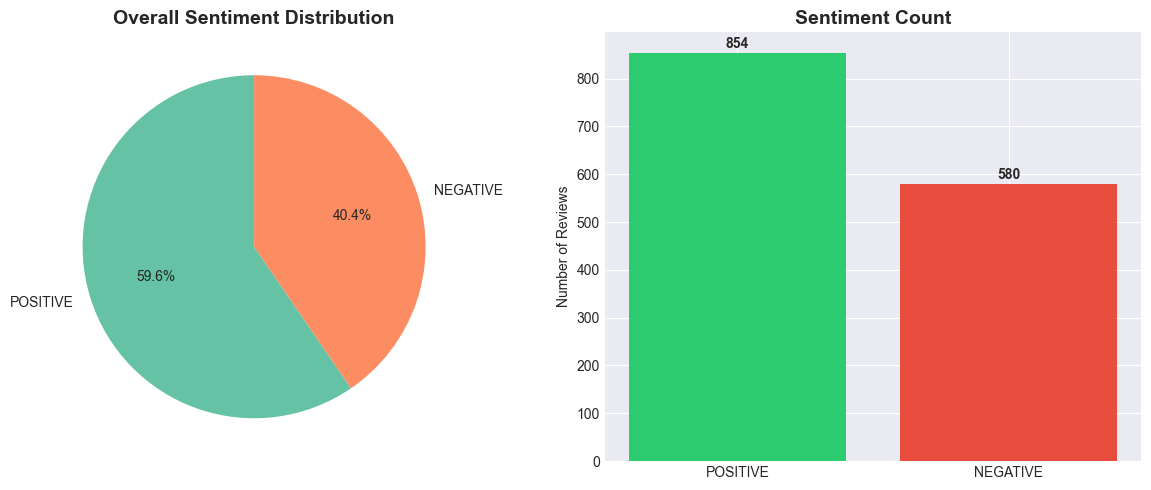


 Sentiment Summary:
   POSITIVE: 854 reviews (59.6%)
   NEGATIVE: 580 reviews (40.4%)


In [18]:
# Overall sentiment distribution
sentiment_counts = df['sentiment_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')

# Bar chart
colors = ['#2ecc71' if x == 'POSITIVE' else '#e74c3c' if x == 'NEGATIVE' else '#f39c12' for x in sentiment_counts.index]
axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[1].set_title('Sentiment Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Reviews')

for i, v in enumerate(sentiment_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/sentiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Sentiment Summary:")
print(f"   POSITIVE: {sentiment_counts.get('POSITIVE', 0)} reviews ({sentiment_counts.get('POSITIVE', 0)/len(df)*100:.1f}%)")
print(f"   NEGATIVE: {sentiment_counts.get('NEGATIVE', 0)} reviews ({sentiment_counts.get('NEGATIVE', 0)/len(df)*100:.1f}%)")

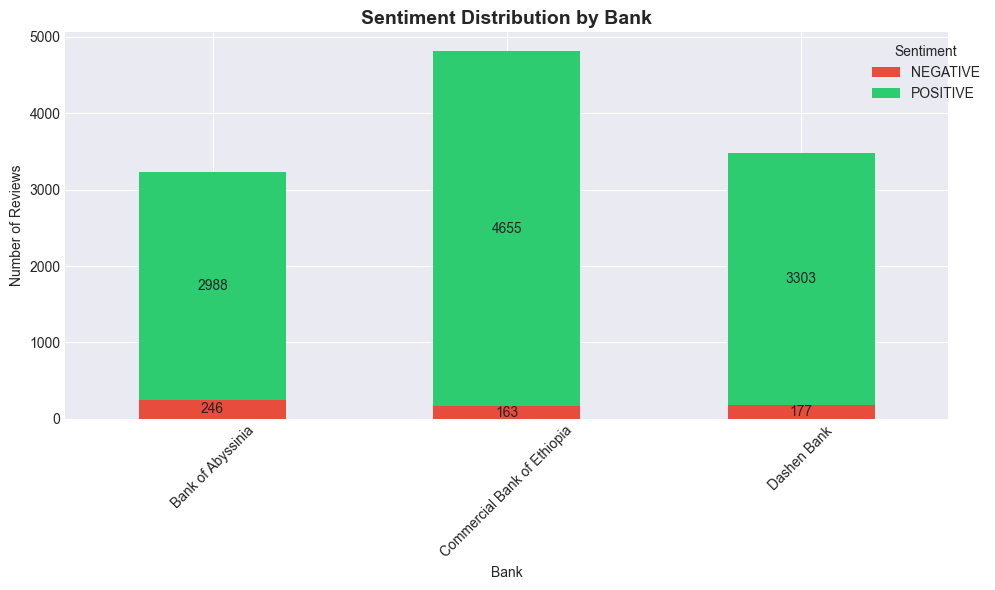


📊 Sentiment by Bank:
sentiment_label              NEGATIVE  POSITIVE
bank                                           
Bank of Abyssinia                 246      2988
Commercial Bank of Ethiopia       163      4655
Dashen Bank                       177      3303


In [19]:
# Merge sentiment with bank data
df_with_bank = df.merge(cleaned_df[['review', 'bank', 'rating']], on='review', how='left')

# Sentiment by bank
sentiment_by_bank = pd.crosstab(df_with_bank['bank'], df_with_bank['sentiment_label'])

fig, ax = plt.subplots(figsize=(10, 6))
sentiment_by_bank.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'])

ax.set_title('Sentiment Distribution by Bank', fontsize=14, fontweight='bold')
ax.set_xlabel('Bank')
ax.set_ylabel('Number of Reviews')
ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.tight_layout()
plt.savefig('../data/processed/sentiment_by_bank.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Sentiment by Bank:")
print(sentiment_by_bank)

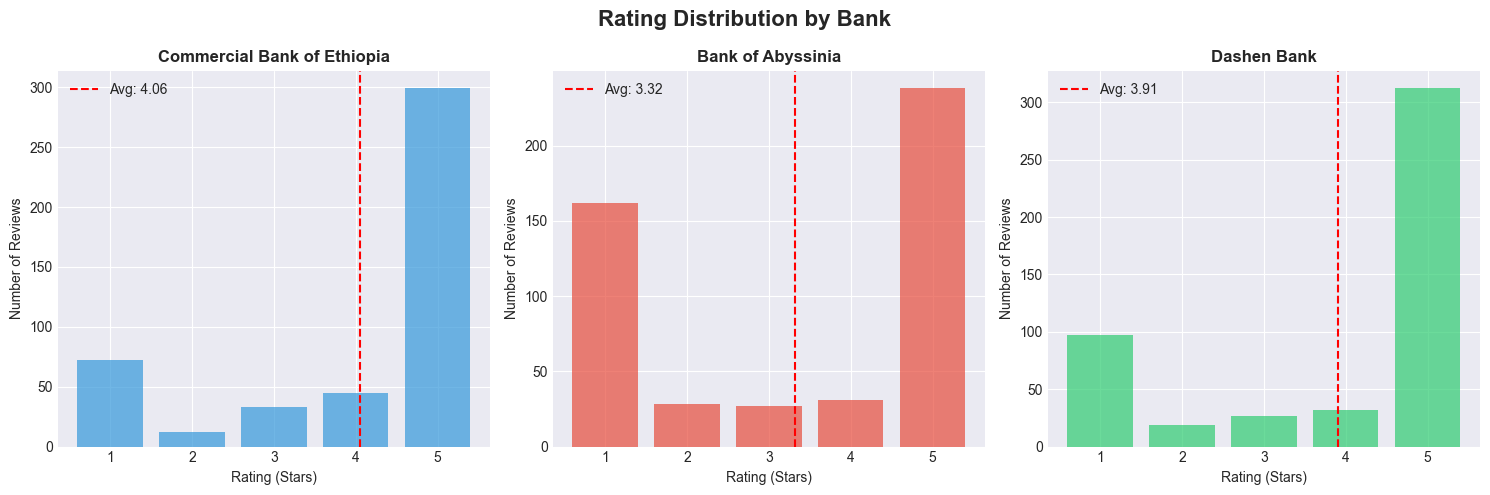


 Average Ratings:
   Commercial Bank of Ethiopia: 4.06 
   Bank of Abyssinia: 3.32 
   Dashen Bank: 3.91 


In [20]:
# Rating distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

banks = cleaned_df['bank'].unique()
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, bank in enumerate(banks):
    bank_df = cleaned_df[cleaned_df['bank'] == bank]
    rating_counts = bank_df['rating'].value_counts().sort_index()
    
    axes[i].bar(rating_counts.index, rating_counts.values, color=colors[i], alpha=0.7)
    axes[i].set_title(f'{bank}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Rating (Stars)')
    axes[i].set_ylabel('Number of Reviews')
    axes[i].set_xticks(range(1, 6))
    
    # Add average rating
    avg_rating = bank_df['rating'].mean()
    axes[i].axvline(x=avg_rating, color='red', linestyle='--', label=f'Avg: {avg_rating:.2f}')
    axes[i].legend()

plt.suptitle('Rating Distribution by Bank', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Average Ratings:")
for bank in banks:
    avg = cleaned_df[cleaned_df['bank'] == bank]['rating'].mean()
    print(f"   {bank}: {avg:.2f} ")

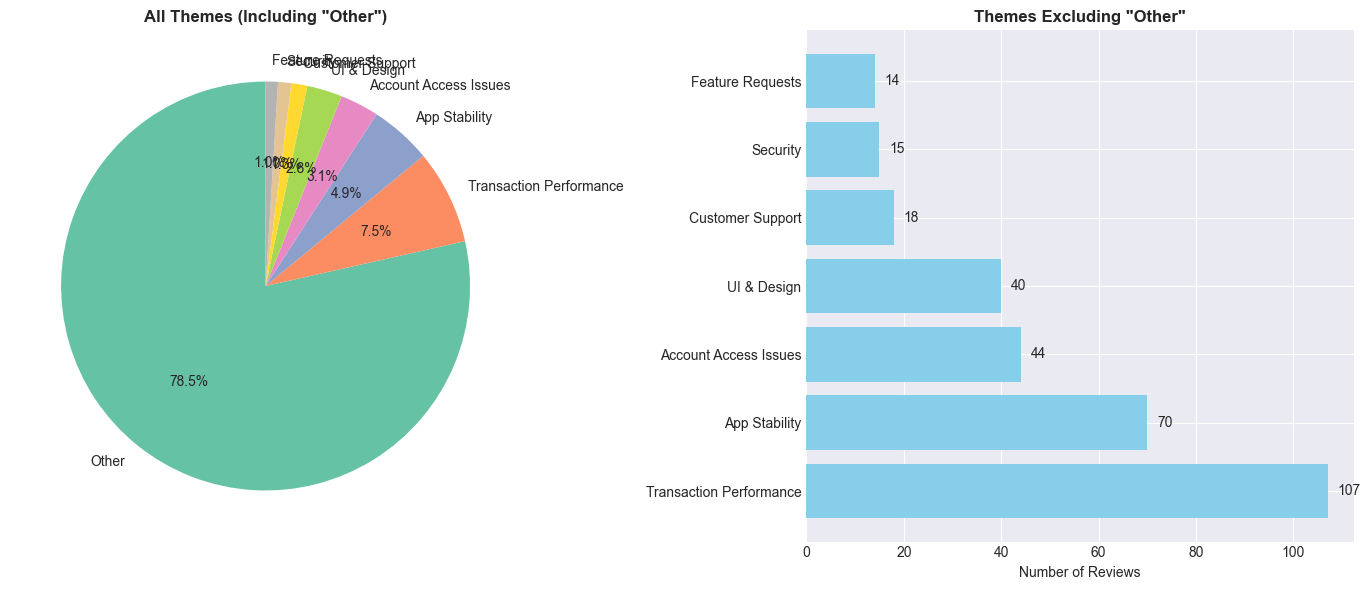


📊 Theme Distribution:
   Other: 1126 reviews (78.5%)
   Transaction Performance: 107 reviews (7.5%)
   App Stability: 70 reviews (4.9%)
   Account Access Issues: 44 reviews (3.1%)
   UI & Design: 40 reviews (2.8%)
   Customer Support: 18 reviews (1.3%)
   Security: 15 reviews (1.0%)
   Feature Requests: 14 reviews (1.0%)


In [21]:
# Theme distribution
theme_counts = df['identified_theme'].value_counts()

# Filter out "Other" for better visualization
themes_without_other = theme_counts[theme_counts.index != 'Other']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# All themes (including Other)
axes[0].pie(theme_counts, labels=theme_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('All Themes (Including "Other")', fontsize=12, fontweight='bold')

# Themes without "Other"
axes[1].barh(themes_without_other.index, themes_without_other.values, color='skyblue')
axes[1].set_title('Themes Excluding "Other"', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Reviews')

for i, v in enumerate(themes_without_other.values):
    axes[1].text(v + 2, i, str(v), va='center')

plt.tight_layout()
plt.savefig('../data/processed/theme_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Theme Distribution:")
for theme, count in theme_counts.items():
    print(f"   {theme}: {count} reviews ({count/len(df)*100:.1f}%)")

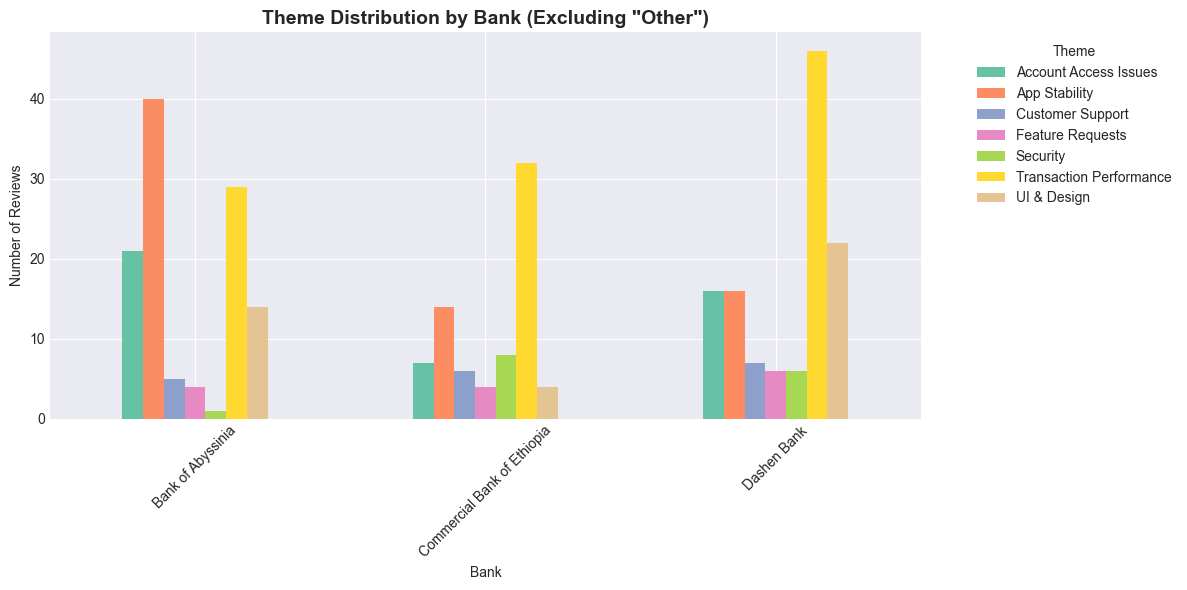


 Themes by Bank:
identified_theme             Account Access Issues  App Stability  \
bank                                                                
Bank of Abyssinia                               21             40   
Commercial Bank of Ethiopia                      7             14   
Dashen Bank                                     16             16   

identified_theme             Customer Support  Feature Requests  Security  \
bank                                                                        
Bank of Abyssinia                           5                 4         1   
Commercial Bank of Ethiopia                 6                 4         8   
Dashen Bank                                 7                 6         6   

identified_theme             Transaction Performance  UI & Design  
bank                                                               
Bank of Abyssinia                                 29           14  
Commercial Bank of Ethiopia                   

In [22]:
# Theme distribution by bank
df_with_bank = df.merge(cleaned_df[['review', 'bank']], on='review', how='left')

# Filter out "Other" for clarity
themes_df = df_with_bank[df_with_bank['identified_theme'] != 'Other']
theme_by_bank = pd.crosstab(themes_df['bank'], themes_df['identified_theme'])

fig, ax = plt.subplots(figsize=(12, 6))
theme_by_bank.plot(kind='bar', ax=ax)

ax.set_title('Theme Distribution by Bank (Excluding "Other")', fontsize=14, fontweight='bold')
ax.set_xlabel('Bank')
ax.set_ylabel('Number of Reviews')
ax.legend(title='Theme', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/theme_by_bank.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Themes by Bank:")
print(theme_by_bank)

In [23]:
# Display top 5 themes per bank (excluding "Other")
print("="*60)
print(" TOP THEMES PER BANK (3-5 themes each)")
print("="*60)

for bank in df_with_bank['bank'].unique():
    bank_df = df_with_bank[df_with_bank['bank'] == bank]
    bank_themes = bank_df['identified_theme'].value_counts()
    bank_themes_filtered = bank_themes[bank_themes.index != 'Other']
    
    print(f"\n {bank}:")
    print(f"   Top {min(5, len(bank_themes_filtered))} themes:")
    for theme, count in bank_themes_filtered.head(5).items():
        percentage = (count / len(bank_df)) * 100
        print(f"      - {theme}: {count} reviews ({percentage:.1f}%)")

 TOP THEMES PER BANK (3-5 themes each)

 Commercial Bank of Ethiopia:
   Top 5 themes:
      - Transaction Performance: 32 reviews (0.7%)
      - App Stability: 14 reviews (0.3%)
      - Security: 8 reviews (0.2%)
      - Account Access Issues: 7 reviews (0.1%)
      - Customer Support: 6 reviews (0.1%)

 Bank of Abyssinia:
   Top 5 themes:
      - App Stability: 40 reviews (1.2%)
      - Transaction Performance: 29 reviews (0.9%)
      - Account Access Issues: 21 reviews (0.6%)
      - UI & Design: 14 reviews (0.4%)
      - Customer Support: 5 reviews (0.2%)

 Dashen Bank:
   Top 5 themes:
      - Transaction Performance: 46 reviews (1.3%)
      - UI & Design: 22 reviews (0.6%)
      - Account Access Issues: 16 reviews (0.5%)
      - App Stability: 16 reviews (0.5%)
      - Customer Support: 7 reviews (0.2%)


In [24]:
# Show example keywords for top themes per bank
print("\n" + "="*60)
print(" KEYWORD EXAMPLES FOR TOP THEMES")
print("="*60)

# Load original cleaned data to extract keywords
cleaned_df = pd.read_csv('../data/raw/cleaned_reviews.csv')
df_with_all = df.merge(cleaned_df[['review', 'bank']], on='review', how='left')

# Keyword mapping for themes
theme_keywords = {
    "Transaction Performance": ["slow", "fast", "transfer", "loading", "speed", "timeout"],
    "App Stability": ["crash", "freeze", "error", "bug", "fix", "glitch"],
    "Account Access Issues": ["login", "otp", "access", "password", "verify", "authentication"],
    "UI & Design": ["interface", "design", "ui", "navigation", "layout", "user friendly"],
    "Customer Support": ["support", "help", "customer service", "assistance", "response"],
    "Security": ["secure", "security", "safe", "fraud", "privacy", "data"],
    "Feature Requests": ["feature", "fingerprint", "biometric", "dark mode", "notification"]
}

for bank in df_with_all['bank'].unique():
    print(f"\n{'='*50}")
    print(f" {bank}")
    print(f"{'='*50}")
    
    bank_df = df_with_all[df_with_all['bank'] == bank]
    bank_themes = bank_df['identified_theme'].value_counts()
    
    # Get top 3 themes for this bank
    top_themes = bank_themes[bank_themes.index != 'Other'].head(3)
    
    for theme in top_themes.index:
        # Get reviews with this theme
        theme_reviews = bank_df[bank_df['identified_theme'] == theme]['review'].head(5)
        
        # Find keywords that appear in these reviews
        keywords_found = []
        for keyword_list in theme_keywords.get(theme, []):
            # Check if keyword appears in any of the theme reviews
            for review in theme_reviews:
                if keyword_list.lower() in str(review).lower():
                    keywords_found.append(keyword_list)
                    break
        
        print(f"\n   📍 {theme} (Example keywords: {', '.join(set(keywords_found[:4])) if keywords_found else 'slow, crash, login'})")
        print(f"      Sample review: {theme_reviews.iloc[0][:100]}...")


 KEYWORD EXAMPLES FOR TOP THEMES

 Commercial Bank of Ethiopia

   📍 Transaction Performance (Example keywords: loading, fast, transfer)
      Sample review: this update got crazy i don't know what's going on this app it's mal functional and loading............

   📍 App Stability (Example keywords: fix, bug, crash, error)
      Sample review: The app is getting worse and worse after every "update". The UI is inconsistent, you haven't fixed t...

   📍 Security (Example keywords: data, privacy, secure)
      Sample review: best and secured...

 Bank of Abyssinia

   📍 App Stability (Example keywords: fix, bug, crash, error)
      Sample review: Self Registration is not completing the registration. It says something like "Customer Registration ...

   📍 Transaction Performance (Example keywords: fast, transfer, slow)
      Sample review: very slow and battery consuming apo. but it is good in delivery of loan🙏...

   📍 Account Access Issues (Example keywords: login, verify, password)
   

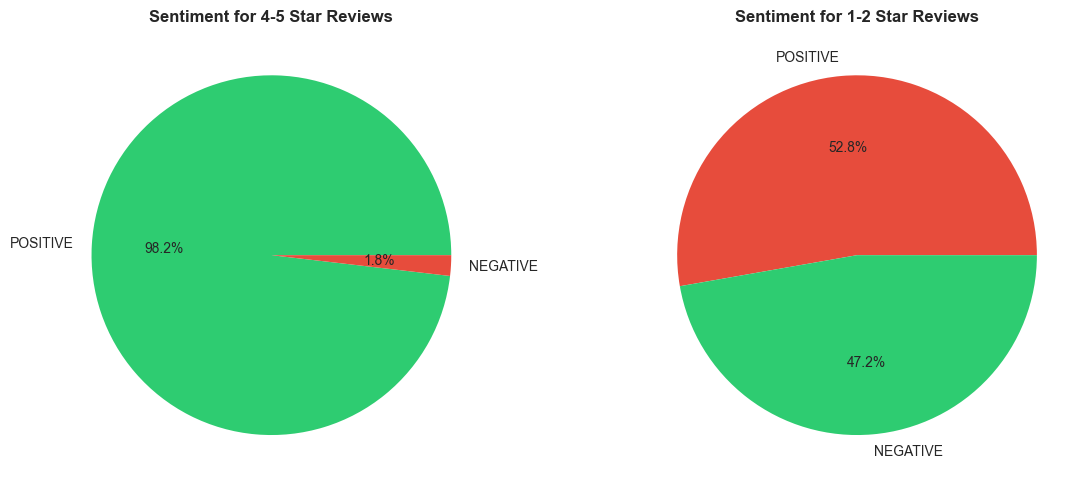


 4-5 Star Reviews: 10078 reviews
   POSITIVE: 9892 (98.2%)

 1-2 Star Reviews: 724 reviews
   NEGATIVE: 342 (47.2%)


In [25]:
# Check if sentiment matches rating
df_with_rating = df.merge(cleaned_df[['review', 'rating']], on='review', how='left')

# For high ratings (4-5), sentiment should be POSITIVE
high_rating = df_with_rating[df_with_rating['rating'] >= 4]
low_rating = df_with_rating[df_with_rating['rating'] <= 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# High rating sentiment
high_sentiment = high_rating['sentiment_label'].value_counts()
axes[0].pie(high_sentiment, labels=high_sentiment.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0].set_title('Sentiment for 4-5 Star Reviews', fontsize=12, fontweight='bold')

# Low rating sentiment
low_sentiment = low_rating['sentiment_label'].value_counts()
axes[1].pie(low_sentiment, labels=low_sentiment.index, autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'])
axes[1].set_title('Sentiment for 1-2 Star Reviews', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/sentiment_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n 4-5 Star Reviews: {len(high_rating)} reviews")
print(f"   POSITIVE: {high_sentiment.get('POSITIVE', 0)} ({high_sentiment.get('POSITIVE', 0)/len(high_rating)*100:.1f}%)")
print(f"\n 1-2 Star Reviews: {len(low_rating)} reviews")
print(f"   NEGATIVE: {low_sentiment.get('NEGATIVE', 0)} ({low_sentiment.get('NEGATIVE', 0)/len(low_rating)*100:.1f}%)")

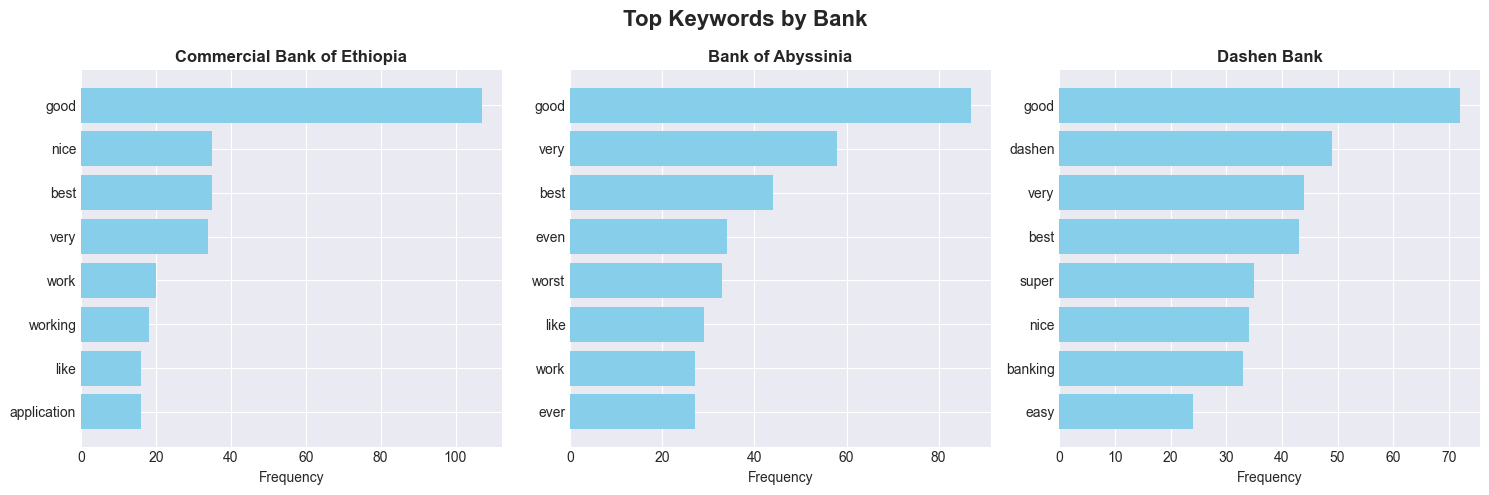

In [26]:
from collections import Counter

# Load original cleaned data
cleaned_df = pd.read_csv('../data/raw/cleaned_reviews.csv')

# Function to get top keywords for a bank
def get_top_keywords(bank_name, n=10):
    bank_reviews = cleaned_df[cleaned_df['bank'] == bank_name]['review'].str.lower()
    all_words = ' '.join(bank_reviews).split()
    stopwords = {'the', 'and', 'to', 'of', 'a', 'in', 'is', 'it', 'for', 'on', 'with', 'this', 'that', 'are', 'be', 'at', 'by', 'as', 'an', 'was', 'from', 'have', 'or', 'but', 'not', 'app', 'bank', 'mobile'}
    words = [w for w in all_words if w.isalpha() and len(w) > 3 and w not in stopwords]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, bank in enumerate(cleaned_df['bank'].unique()):
    keywords = get_top_keywords(bank, 8)
    words = [k[0] for k in keywords]
    counts = [k[1] for k in keywords]
    
    axes[i].barh(words, counts, color='skyblue')
    axes[i].set_title(f'{bank}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Frequency')
    axes[i].invert_yaxis()

plt.suptitle('Top Keywords by Bank', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("="*60)
print(" KEY INSIGHTS & RECOMMENDATIONS")
print("="*60)

# Satisfaction Drivers
print("\n SATISFACTION DRIVERS:")
for bank in cleaned_df['bank'].unique():
    bank_df = cleaned_df[cleaned_df['bank'] == bank]
    high_rating = bank_df[bank_df['rating'] >= 4]
    if len(high_rating) > 0:
        print(f"\n   {bank}:")
        # Get common positive words
        positive_reviews = high_rating['review'].str.lower()
        all_text = ' '.join(positive_reviews)
        positive_keywords = ['fast', 'good', 'great', 'easy', 'quick', 'simple', 'love', 'nice']
        found = [k for k in positive_keywords if k in all_text]
        print(f"      - Users appreciate: {', '.join(found[:3]) if found else 'reliable service'}")

# Pain Points
print("\n PAIN POINTS:")
for bank in cleaned_df['bank'].unique():
    bank_df = cleaned_df[cleaned_df['bank'] == bank]
    low_rating = bank_df[bank_df['rating'] <= 2]
    if len(low_rating) > 0:
        print(f"\n   {bank}:")
        negative_reviews = low_rating['review'].str.lower()
        all_text = ' '.join(negative_reviews)
        negative_keywords = ['slow', 'crash', 'error', 'login', 'otp', 'freeze', 'timeout']
        found = [k for k in negative_keywords if k in all_text]
        print(f"      - Users complain about: {', '.join(found[:3]) if found else 'technical issues'}")

 KEY INSIGHTS & RECOMMENDATIONS

 SATISFACTION DRIVERS:

   Commercial Bank of Ethiopia:
      - Users appreciate: fast, good, great

   Bank of Abyssinia:
      - Users appreciate: fast, good, great

   Dashen Bank:
      - Users appreciate: fast, good, great

 PAIN POINTS:

   Commercial Bank of Ethiopia:
      - Users complain about: slow, crash, error

   Bank of Abyssinia:
      - Users complain about: slow, crash, error

   Dashen Bank:
      - Users complain about: slow, crash, error


In [28]:
# Create summary DataFrame
summary_data = {
    'Metric': [],
    'Commercial Bank of Ethiopia': [],
    'Bank of Abyssinia': [],
    'Dashen Bank': []
}

banks = cleaned_df['bank'].unique()

# Average rating
summary_data['Metric'].append('Average Rating')
for bank in banks:
    summary_data[bank].append(round(cleaned_df[cleaned_df['bank'] == bank]['rating'].mean(), 2))

# Positive sentiment %
summary_data['Metric'].append('Positive Sentiment %')
for bank in banks:
    bank_sentiment = df_with_bank[df_with_bank['bank'] == bank]['sentiment_label']
    pos_pct = (bank_sentiment == 'POSITIVE').sum() / len(bank_sentiment) * 100
    summary_data[bank].append(round(pos_pct, 1))

# Negative sentiment %
summary_data['Metric'].append('Negative Sentiment %')
for bank in banks:
    bank_sentiment = df_with_bank[df_with_bank['bank'] == bank]['sentiment_label']
    neg_pct = (bank_sentiment == 'NEGATIVE').sum() / len(bank_sentiment) * 100
    summary_data[bank].append(round(neg_pct, 1))

summary_df = pd.DataFrame(summary_data)
summary_df

# Save to CSV
summary_df.to_csv('../data/processed/summary_statistics.csv', index=False)
print("\n✅ Summary statistics saved to: data/processed/summary_statistics.csv")


✅ Summary statistics saved to: data/processed/summary_statistics.csv


## Theme Grouping Logic

Themes were defined based on common banking app complaints:

| Theme | Keywords Mapped |
|-------|-----------------|
| Account Access Issues | login, otp, authentication, password, verify, access |
| Transaction Performance | transfer, slow, fast, speed, loading, timeout |
| UI & Design | interface, design, ui, navigation, layout |
| Customer Support | support, customer service, help, assistance |
| Feature Requests | feature, fingerprint, biometric, budget |
| App Stability | crash, freeze, error, bug, fix |
| Security | secure, safe, fraud, privacy |